# Loan Applicant Credit Risk and Approval Readiness Score

This notebook cleans, analyzes, and scores 981 loan applications to build an Approval Readiness Score, a scorecard that estimates how ready each applicant looks for approval.

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv('raw_data.csv')
print("Raw data shape:", df.shape)
df.head()

Raw data shape: (981, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,LP001015,m,Yes,0,Graduate,No,5720,0.0,110.0,360.0,1.0,Urban
1,LP001022,Male,Yes,1,Graduate,No,3076,1500.0,126.0,360.0,1.0,Uban
2,LP001031,Male,Yes,2,Graduate,No,5000,1800.0,208.0,360.0,1.0,Urban
3,LP001035,m,Yes,2,Graduate,No,2340,2546.0,100.0,360.0,NaN,Urban
4,LP001051,Male,No,0,Not Graduate,No,3276,0.0,78.0,360.0,1.0,Urban


## Step 1: Cleaning the Data

The raw file has six problems: inconsistent labels, missing values, mixed data types, no target column, unclear units, and possible duplicates. Each is fixed below.

In [15]:
log = []

# Strip whitespace
str_cols = df.select_dtypes(include='object').columns.tolist() + ['Loan_ID']
str_cols = list(dict.fromkeys(str_cols))
for c in str_cols:
    df[c] = df[c].astype('string').str.strip()

# Fix Gender labels
df['Gender'] = df['Gender'].replace({'m': 'Male', 'f': 'Female'})

# Fix Property_Area typos
area_map = {
    'Urban': 'Urban', 'Uban': 'Urban', 'Urben': 'Urban', 'Urbun': 'Urban', 'Urbn': 'Urban',
    'Semiurban': 'Semiurban', 'Semiurbn': 'Semiurban', 'Semiurben': 'Semiurban', 'Semurban': 'Semiurban',
    'Rural': 'Rural', 'Rurl': 'Rural', 'Rurel': 'Rural', 'Rurall': 'Rural', 'Rual': 'Rural'
}
df['Property_Area'] = df['Property_Area'].map(area_map)

# Dependents: category + numeric version
df['Dependents'] = df['Dependents'].astype('string')

# Fill missing categories with mode
for c in ['Gender', 'Married', 'Self_Employed', 'Dependents']:
    df[c] = df[c].fillna(df[c].mode(dropna=True)[0])

# Fill missing numbers with median
for c in ['LoanAmount', 'Loan_Amount_Term']:
    df[c] = df[c].fillna(df[c].median())

df['Dependents_numeric'] = df['Dependents'].replace({'3+': '3'}).astype('Float64')

# Credit_History: keep missingness as its own category
df['Credit_History_Status'] = df['Credit_History'].map({1.0: 'Has Credit History', 0.0: 'No Credit History'})
df['Credit_History_Status'] = df['Credit_History_Status'].fillna('Unknown/Not on File')

# Remove duplicates
df = df.drop_duplicates(subset=['Loan_ID'])

# Fix data types
for c in ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']:
    df[c] = df[c].astype(float)

# New columns for analysis
df['TotalIncome'] = df['ApplicantIncome'] + df['CoapplicantIncome']
df['LoanAmount_Actual'] = df['LoanAmount'] * 1000
df['Loan_to_Income_Ratio'] = df['LoanAmount_Actual'] / df['TotalIncome'].replace(0, np.nan)
df['LoanIncomeRatio'] = df['LoanAmount'] / (df['TotalIncome'] / 1000 + 1)
df['Has_Coapplicant'] = (df['CoapplicantIncome'] > 0).astype(int)

print("Cleaned data shape:", df.shape)
print("Missing values remaining:")
print(df.isnull().sum())

Cleaned data shape: (981, 19)
Missing values remaining:
Loan_ID                   0
Gender                    0
Married                   0
Dependents                0
Education                 0
Self_Employed             0
ApplicantIncome           0
CoapplicantIncome         0
LoanAmount                0
Loan_Amount_Term          0
Credit_History           79
Property_Area             0
Dependents_numeric        0
Credit_History_Status     0
TotalIncome               0
LoanAmount_Actual         0
Loan_to_Income_Ratio      0
LoanIncomeRatio           0
Has_Coapplicant           0
dtype: int64


## Step 2: Exploring the Data

Six questions about credit history, checked against the cleaned data.

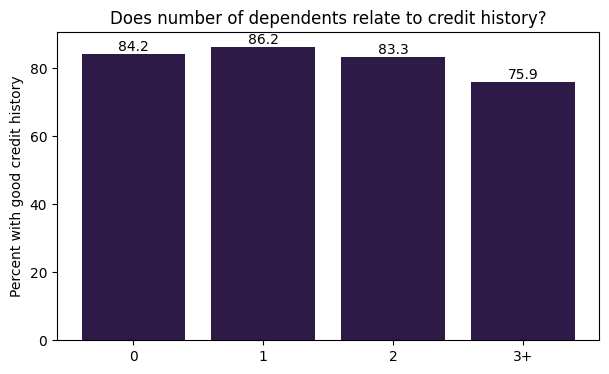

In [16]:
import matplotlib.pyplot as plt

rate_dep = (df.groupby("Dependents")["Credit_History"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rate_dep.index, rate_dep.values, color="#2E1A47")
ax.set_title("Does number of dependents relate to credit history?")
ax.set_ylabel("Percent with good credit history")
ax.bar_label(bars, fmt="%.1f")
plt.show()

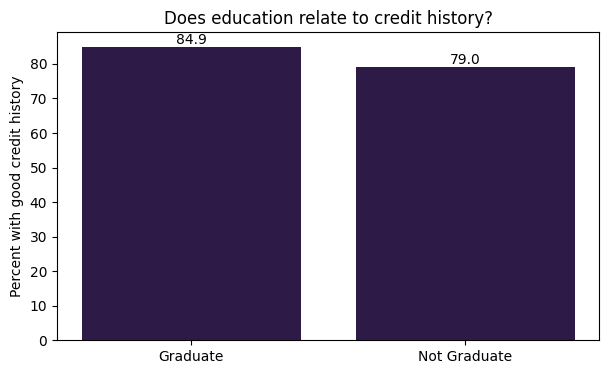

In [17]:
rate_edu = (df.groupby("Education")["Credit_History"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rate_edu.index, rate_edu.values, color="#2E1A47")
ax.set_title("Does education relate to credit history?")
ax.set_ylabel("Percent with good credit history")
ax.bar_label(bars, fmt="%.1f")
plt.show()

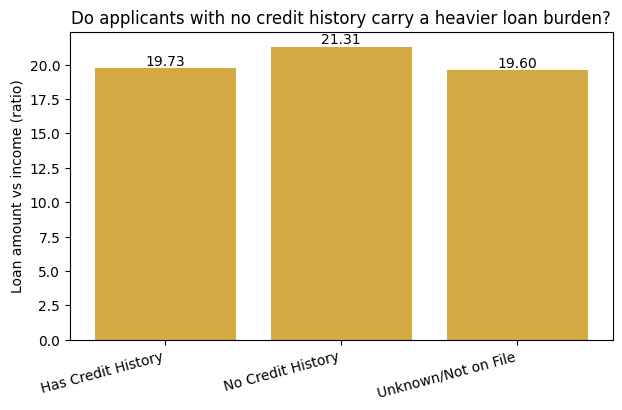

In [18]:
ratio = df.groupby("Credit_History_Status")["LoanIncomeRatio"].mean().round(2)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(ratio.index, ratio.values, color="#D4A843")
ax.set_title("Do applicants with no credit history carry a heavier loan burden?")
ax.set_ylabel("Loan amount vs income (ratio)")
ax.bar_label(bars, fmt="%.2f")
plt.xticks(rotation=15, ha="right")
plt.show()

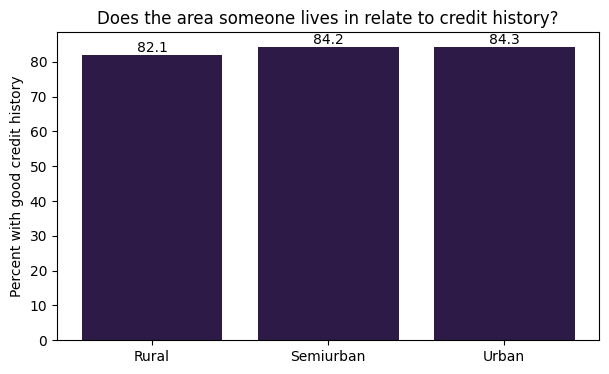

In [19]:
rate_area = (df.groupby("Property_Area")["Credit_History"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rate_area.index, rate_area.values, color="#2E1A47")
ax.set_title("Does the area someone lives in relate to credit history?")
ax.set_ylabel("Percent with good credit history")
ax.bar_label(bars, fmt="%.1f")
plt.show()

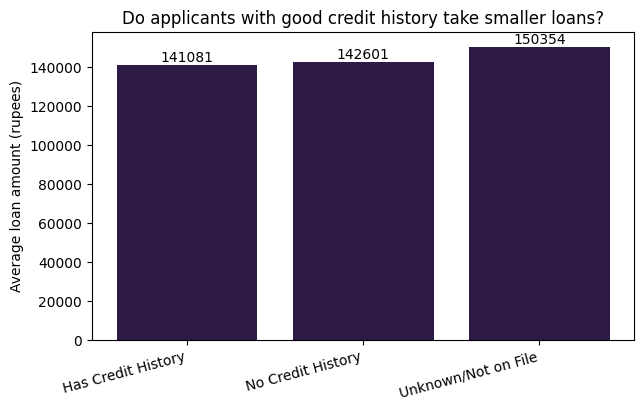

In [20]:
avg_loan = df.groupby("Credit_History_Status")["LoanAmount_Actual"].mean().round(0)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(avg_loan.index, avg_loan.values, color="#2E1A47")
ax.set_title("Do applicants with good credit history take smaller loans?")
ax.set_ylabel("Average loan amount (rupees)")
ax.bar_label(bars, fmt="%.0f")
plt.xticks(rotation=15, ha="right")
plt.show()

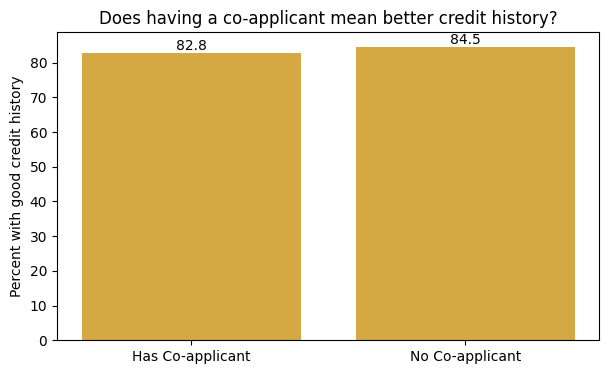

In [21]:
df["Coapplicant_Label"] = df["Has_Coapplicant"].map({0: "No Co-applicant", 1: "Has Co-applicant"})
rate_coapp = (df.groupby("Coapplicant_Label")["Credit_History"].mean() * 100).round(1)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(rate_coapp.index, rate_coapp.values, color="#D4A843")
ax.set_title("Does having a co-applicant mean better credit history?")
ax.set_ylabel("Percent with good credit history")
ax.bar_label(bars, fmt="%.1f")
plt.show()

## Step 3: The Approval Readiness Score

A 100-point scorecard: Credit History (40), Loan-to-Income Ratio (25), Applicant Stability (20), Employment Type (10), and Collateral/Property Area (5).

In [22]:
def credit_score(status):
    return {"Has Credit History": 40, "Unknown/Not on File": 20, "No Credit History": 8}[status]

def ratio_score(ratio):
    if pd.isna(ratio): return 12
    if ratio <= 18: return 25
    elif ratio <= 26: return 18
    elif ratio <= 35: return 10
    else: return 3

def stability_score(row):
    pts = 5 if row["Married"] == "Yes" else 2
    pts += 5 if row["Education"] == "Graduate" else 2
    pts += 5 if row["Dependents"] == "0" else 2
    pts += 5 if row["Loan_Amount_Term"] >= 360 else 3
    return pts

def employment_score(row):
    return 10 if row["Self_Employed"] == "No" else 6

def collateral_score(area):
    return {"Urban": 5, "Semiurban": 3, "Rural": 2}[area]

df["Approval_Likelihood_Score"] = (
    df["Credit_History_Status"].apply(credit_score) +
    df["Loan_to_Income_Ratio"].apply(ratio_score) +
    df.apply(stability_score, axis=1) +
    df.apply(employment_score, axis=1) +
    df["Property_Area"].apply(collateral_score)
)

df["Likelihood_Band"] = df["Approval_Likelihood_Score"].apply(
    lambda s: "High" if s >= 70 else ("Medium" if s >= 50 else "Low")
)

df["Likelihood_Band"].value_counts(normalize=True).mul(100).round(1)

Likelihood_Band
High      79.4
Medium    14.4
Low        6.2
Name: proportion, dtype: float64

## Conclusion

Credit history drives most of the score. Applicants with no credit history ask for proportionally bigger loans. Loan size, having a co-applicant, and self-employment status do not clearly signal higher risk in this data. About 79% of applicants score High, 14% Medium, and 6% Low, which supports routing applications by band instead of treating every case the same.